<a href="https://colab.research.google.com/github/gbaranaos/iele756-region-4/blob/main/iele756.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Tarea 0 --- IELE756
#Team members:** Guillermo Barañao, [Nombre compañero]
#Comuna:** Santiago
#Código comuna:** 13101
#Date:** 15-03-2026

import pandas as pd
print("Hello, IELE756!")
print(f"pandas version: {pd.__version__}")

Hello, IELE756!
pandas version: 2.2.2


In [13]:
## Parte 1: Censo 2024

#En esta sección se carga la tabla de personas del Censo 2024, se revisa la estructura general del dataset
import pandas as pd
persona = pd.read_parquet(
"/content/personas_censo2024.parquet",
columns=["region", "comuna", "sexo", "edad",
"p27_nacionalidad", "p27_nacionalidad_rec",
"escolaridad", "sit_fuerza_trabajo"],
)

print("SHAPE:")
print(persona.shape)

print("\nDTYPES:")
print(persona.dtypes)

print("\nHEAD(10):")
display(persona.head(10))

print("\nINFO:")
persona.info()

#Se filtran los datos para la comuna de Santiago.
my_region = persona[persona["region"] == 13101 ]
print(f"Rows in my region: {len(my_region):,}")

#Finalmente, se observa la distribución de nacionalidad y calculo el porcentaje de personas extranjeras.
foreign = my_comuna["p27_nacionalidad_rec"] \
.value_counts(normalize=True)
print(f"% foreign-born: {foreign.get('Extranjero', 0):.1%}")

SHAPE:
(18480432, 8)

DTYPES:
region                    int32
comuna                    int32
sexo                      int32
edad                      int32
p27_nacionalidad          int32
p27_nacionalidad_rec      int32
escolaridad               int32
sit_fuerza_trabajo      float64
dtype: object

HEAD(10):


,region,comuna,sexo,edad,p27_nacionalidad,p27_nacionalidad_rec,escolaridad,sit_fuerza_trabajo
0,5,5802,2,80,1,1,17,3.0
1,5,5802,1,52,1,1,14,1.0
2,5,5802,2,45,1,1,12,1.0
3,5,5802,2,8,1,1,2,NaN
4,4,4303,1,69,1,1,12,3.0
5,4,4303,2,65,1,1,12,3.0
6,4,4303,1,58,1,1,15,1.0
7,11,11202,2,-66,-66,1,8,1.0
8,11,11202,1,-66,-66,1,5,1.0
9,11,11202,1,-66,-66,1,3,NaN



INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18480432 entries, 0 to 18480431
Data columns (total 8 columns):
 #   Column                Dtype  
---  ------                -----  
 0   region                int32  
 1   comuna                int32  
 2   sexo                  int32  
 3   edad                  int32  
 4   p27_nacionalidad      int32  
 5   p27_nacionalidad_rec  int32  
 6   escolaridad           int32  
 7   sit_fuerza_trabajo    float64
dtypes: float64(1), int32(7)
memory usage: 634.5 MB
Rows in my region: 0
% foreign-born: 0.0%


/tmp/ipykernel_910/3593786952.py:7: DtypeWarning: Columns (6,11,12,13,14,15,16,17,18,19,20,22,23,24,25,26,27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  eno = pd.read_csv(


Total rows: 333,300
['etapa_clinica', 'region', 'seremi', 'nacionalidad', 'cie_10_diagnostico', 'diagnostico', 'Autóctono', 'anho_notificacion', 'ENO', 'pueblo_indigena', 'nombre_instruccion', 'presenta_sintomas', 'sintomas', 'consumo_agua_no_potable', 'antecedente_teniasis', 'imagenologia', 'manifestaciones', 'existe_coinfeccion', 'via_transmision', 'n_parejas_sexuales', 'uso_preservativo', 'pais_contagio', 'paciente_inmunosuprimido', 'vih', 'pareja', 'exantema_mpox', 'factores_exposicion', 'neumonia', 'contacto_aves', 'genotipo_1', 'recuento_linfocitos', 'clasificacion_final_vih', 'etapa_vih_sida', 'hospitalizacion', 'nombre_primer_sintoma', 'SeroGrupo', 'sexo', 'grupo_edad', 'codigo_comuna_residencia']
Rows in my comuna: 12,186
anho_notificacion
2007     121
2008     157
2009     303
2010     186
2011     424
2012     307
2013     349
2014     405
2015     415
2016     424
2017    1343
2018    1881
2019    1145
2020     645
2021     527
2022     854
2023    1746
2024     954
Name: c

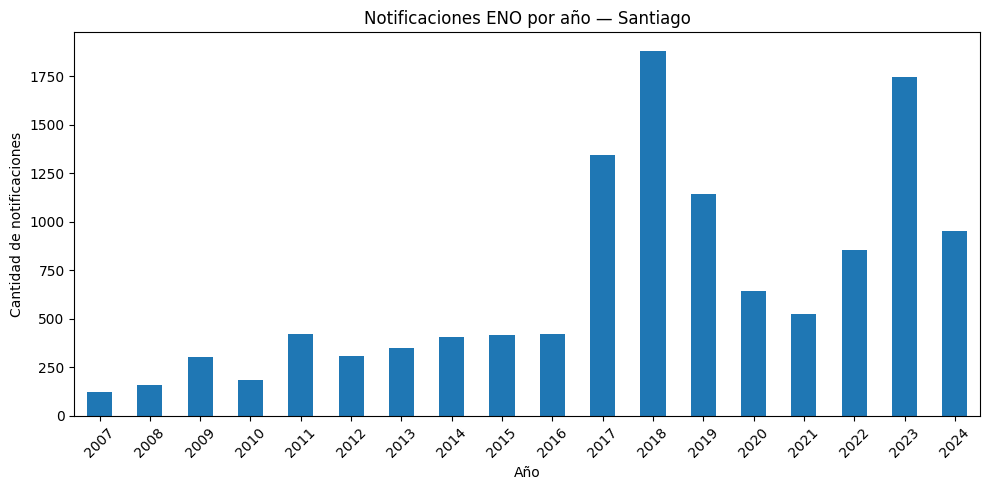

In [9]:
## Parte 2: ENO — Enfermedades de Notificación Obligatoria

#Se la base ENO, Se revisan sus columnas y se filtran los registros correspondientes a la comuna de Santiago.

import pandas as pd
import matplotlib.pyplot as plt
eno = pd.read_csv(
    "/content/20241218_base_eno_final.csv",
    sep=";", encoding="utf-8-sig", )
print(f"Total rows: {len(eno):,}")
print(eno.columns.tolist())

eno_codigo_comuna_residencia = eno[eno["codigo_comuna_residencia"] == "13101"]
print(f"Rows in my comuna: {len(eno_codigo_comuna_residencia):,}")

#Calculó las notificaciones por año.
notif_year = eno_codigo_comuna_residencia["anho_notificacion"].value_counts().sort_index()
print(notif_year)

#Identificar las 5 enfermedades más frecuentes
top5_eno = eno_codigo_comuna_residencia["ENO"].value_counts().head(5)
print(top5_eno)

#Identificar la nacionalidad de los pacientes
nac_eno = eno_codigo_comuna_residencia["nacionalidad"].value_counts(dropna=False)
print(nac_eno)

#Tabla de notificaciones por año
plt.figure(figsize=(10, 5))
notif_year.plot(kind="bar")
plt.title("Notificaciones ENO por año — Santiago")
plt.xlabel("Año")
plt.ylabel("Cantidad de notificaciones")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
## Parte 3: GRD — Egresos Hospitalarios


import zipfile
#En esta sección cargo el archivo GRD del año 2024 directamente desde el archivo ZIP, usando solo las columnas necesarias para ahorrar memoria.
cols = [
    "COMUNA", "NACIONALIDAD", "SEXO", "DIAGNOSTICO1",
    "FECHA_INGRESO", "FECHAALTA",
    "IR_29301_SEVERIDAD", "IR_29301_COD_GRD"
]

with zipfile.ZipFile("/content/GRD_PUBLICO_2024.zip") as z:
    with z.open("GRD_PUBLICO_2024.txt") as f:
        grd = pd.read_csv(
            f,
            sep="|",
            usecols=cols,
            low_memory=False,
            encoding="latin-1"
        )

print(f"Total discharges: {len(grd):,}")
display(grd.head())

#Filtro de registros para la comuna de Santiago.
my_comunas = ["SANTIAGO"] # your region's comunas
grd_region = grd[grd["COMUNA"].isin(my_comunas)]
print(f"Discharges in my region: {len(grd_region):,}")

# Cruce con la tabla CIE-10 y se obtienen los 5 diagnósticos más frecuentes.
cie10 = pd.read_excel("/content/CIE-10.xlsx",
sheet_name="CIE 10")
grd_region = grd_region.merge(
cie10[["Código", "Descripción", "Capítulo"]],
left_on="DIAGNOSTICO1", right_on="Código",
how="left")

grd_region["Descripción"].value_counts().head(5)

Total discharges: 1,085,813


,SEXO,COMUNA,NACIONALIDAD,FECHA_INGRESO,FECHAALTA,DIAGNOSTICO1,IR_29301_COD_GRD,IR_29301_SEVERIDAD
0,MUJER,VILLA ALEMANA,CHILE,2024-03-23,2024-03-23,H26.9,022360,0
1,MUJER,VIÑA DEL MAR,CHILE,2024-09-26,2024-10-02,M31.1,041023,3
2,HOMBRE,LA SERENA,CHILE,2024-01-22,2024-01-26,K12.2,034141,1
3,HOMBRE,ÑUÑOA,CHILE,2024-04-08,2024-04-14,C61,061203,3
4,MUJER,SAN PEDRO DE LA PAZ,PERÚ,2024-09-24,2024-09-26,K35.8,061131,1


Discharges in my region: 18,799


,count
Descripción,
"Apendicitis aguda, otra y no especificada",432
Cálculo de la vesícula biliar con colecistitis aguda,309
Otras atenciones médicas especificadas,260
"Parto único espontáneo, presentación cefálica de vértice",229
Desgarro perineal de primer grado durante el parto,198
